In [1]:
import psutil
import sys
# !{sys.executable} --version
# !{sys.executable} -m pip install shap --upgrade 
import joblib
import time
from shutil import copy
import numpy as np
import pandas as pd
#import tensorflow as tf
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from sklearn.metrics import mean_absolute_error, r2_score

from glob import glob
import psi4
from helper_CC_ML_spacial import HelperCCEnergy
# from helper_CC_ML import *

from glob import glob
import random
random.seed(0)


  Threads set to 12 by Python driver.


In [2]:
# data_path, model_path = glob(os.path.join(os.path.expanduser("~"),"out/faster_sto_3g_*_20.pkl"))
#data_path, model_path = sorted(glob(os.path.join(os.path.expanduser("~"),"out/faster_sto_3g_*_100.pkl")))
# data_path, model_path = glob(os.path.join(os.path.expanduser("~"),"out/faster_cc_pVDZ*60.pkl"))

In [3]:
model_path = '/mnt/c/Users/Maxim/Documents/Toronto/faster_sto_3g_pVDZ_model_20.pkl'
data_split_path = '/mnt/c/Users/Maxim/Documents/Toronto/faster_sto_3g_pVDZ_data_splits_20.pkl'

In [4]:
with open(model_path,'rb') as m:
    model = joblib.load(m)

with open(data_split_path,'rb') as d:
    data = joblib.load(d)

/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor 

In [5]:
X_train = data['X_train']
X_test = data['X_test']

y_train = data['y_train']
y_test = data['y_test']

In [6]:
# out = model.pr(X_train,y_train)

# These are the machine learning features, these will be useful later

In [7]:
# properties=['Evir1', 'Hvir1', 'Jvir1', 'Kvir1', 'Evir2', 'Hvir2', 'Jvir2', 'Kvir2', 'Eocc1', 'Jocc1', 'Kocc1', 'Hocc1','Eocc2', 'Jocc2', 'Kocc2', 'Hocc2', 'Jia1', 'Jia2', 'Kia1', 'Kia2','diag', 'orbdiff', 'doublecheck', 't2start', 't2mag', 't2sign', 'Jia1mag', 'Jia2mag','Kia1mag', 'Kia2mag','t2']
properties=['Evir1', 'Hvir1', 'Jvir1', 'Kvir1', 'Evir2', 'Hvir2', 'Jvir2', 'Kvir2', 'Eocc1', 'Jocc1', 'Kocc1', 'Hocc1','Eocc2', 'Jocc2', 'Kocc2', 'Hocc2', 'Jia1', 'Jia2', 'Kia1', 'Kia2','diag', 'orbdiff', 'doublecheck', 't2start', 't2mag', 't2sign', 'Jia1mag', 'Jia2mag','Kia1mag', 'Kia2mag']

# Use the basis sets for both Psi4 and PySCF

In [8]:

basis_sets = ['STO-3G','cc-pVDZ','aug-cc-pVDZ']

# Load in the xyz coordinates of the system and then run Psi4 with the Psi4Numpy code we use for DDCC

# TO-DO Max:
- [ ] Create a loop/function that gets the following properties out of the data:
    - [ ] Final energies
    - [ ] Histories (iterations, etc.)
    - [ ] Feature set

In [9]:
data_path = '../machine_learning/data/'
train_path = '/mnt/c/Users/Maxim/Documents/Toronto/train_names_20.txt'

In [10]:

#with open('../check_amplitudes/diatomics/NN.xyz','r') as f:
#    text=f.read()
#qmol = psi4.qcdb.Molecule.from_string(text, dtype='xyz')
#mol = psi4.geometry(qmol.create_psi4_string_from_molecule()+ 'symmetry c1')                

#with open('../machine_learning/data/formaldehyde10.xyz','r') as f:
#    text=f.read()
#mol = psi4.geometry(text)

In [11]:
xyz_files = glob(os.path.join(data_path, '*.xyz'))
xyz_files[:4]

['../machine_learning/data/ammonia10.xyz',
 '../machine_learning/data/ammonia100.xyz',
 '../machine_learning/data/ammonia101.xyz',
 '../machine_learning/data/ammonia102.xyz']

In [12]:
with open(train_path,'r') as f:
    lines = f.readlines()
    
train = [element[:-1] for element in lines]
train[:4]

['ammonia68', 'ammonia72', 'ammonia110', 'methanol78']

In [13]:
train

['ammonia68',
 'ammonia72',
 'ammonia110',
 'methanol78',
 'ethane31',
 'methanol7',
 'water116',
 'ethane46',
 'water34',
 'ethylene69',
 'water41',
 'methanol48',
 'formaldehyde104',
 'methane8',
 'ethane75',
 'ethylene82',
 'ammonia178',
 'ammonia164',
 'ethylene43',
 'ethylene71']

In [14]:
def get_xyz_files(xyz_files, train):
    # Function to get the files that are in xyz_files list, but NOT in train list
    # Args: xyz_files (list), train (list)
    # returns: list
    train_set = set(train)
    other_files = [
        f for f in xyz_files
        if os.path.splitext(os.path.basename(f))[0] not in train_set
    ]
    
    return other_files

In [15]:
files = get_xyz_files(xyz_files, train)
files[:4]

['../machine_learning/data/ammonia10.xyz',
 '../machine_learning/data/ammonia100.xyz',
 '../machine_learning/data/ammonia101.xyz',
 '../machine_learning/data/ammonia102.xyz']

In [16]:
len(xyz_files), len(train), len(files)

(1191, 20, 1171)

In [17]:
sampled_files = random.sample(files, 100)
sampled_files[:5]

['../machine_learning/data/methane198.xyz',
 '../machine_learning/data/methane85.xyz',
 '../machine_learning/data/ammonia176.xyz',
 '../machine_learning/data/formaldehyde143.xyz',
 '../machine_learning/data/water168.xyz']

In [18]:
#with open('out_of_data.txt', 'w') as f:
#    for name in sampled_files:
#        f.write(name + '\n')

In [19]:
with open('out_of_data.txt','r') as f:
    lines = f.readlines()
    
filenames = [element[:-1] for element in lines]
filenames[:4]

['../machine_learning/data/methane72.xyz',
 '../machine_learning/data/ammonia159.xyz',
 '../machine_learning/data/methane5.xyz',
 '../machine_learning/data/water91.xyz']

In [20]:
with open('../machine_learning/data/water101.xyz','r') as f:
    text=f.read()
mol = psi4.geometry(text)                

psi4.core.clean()
psi4.core.be_quiet()

psi4.set_options({'basis': basis_sets[0],
                  'scf_type':     'pk',
                  'reference':    'rohf',
                  'mp2_type':     'conv',
                  'e_convergence': 1e-8,
                  'd_convergence': 1e-8})

rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)      # Hartree-Fock energy
scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)

A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=True)
MP2T2=A.t2start 

MP2E = A.compute_energy(iterate=False)     # MP2 energy
CCSDE = A.compute_energy()             # CCSD energy


MP2History = A.history
MP2History.insert(0, (0,MP2E))
iterations = len(MP2History)
print(f"No. of iterations to converge: {iterations}")

MP2_time_to_converge = A.time_to_converge
print(f"TIME TO CONVERGE: {MP2_time_to_converge}")

features = pd.DataFrame(np.array([getattr(A,attr).flatten() for attr in properties]).T,columns=properties)
print(f"Features: \n{features}")

Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.043 seconds.

CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034836139854761   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.006 seconds!
CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044132517044526   dE = -9.29638E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047020722545799   dE = -2.88821E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048569824824988   dE = -1.54910E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048684428060897   dE = -1.14603E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691808563344   dE = -7.38050E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

# Iterate over molecules

## Normal initialisation

In [22]:
MP2_iter_list = []
MP2_dev = []
for fn in filenames[:3]:
    print(f"Processing {fn}")
    with open(fn,'r') as f:
        text=f.read()
        
    mol = psi4.geometry(text)                
    
    psi4.core.clean()
    psi4.core.be_quiet()
    
    psi4.set_options({'basis': basis_sets[0],
                      'scf_type':     'pk',
                      'reference':    'rohf',
                      'mp2_type':     'conv',
                      'e_convergence': 1e-8,
                      'd_convergence': 1e-8})
    
    rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)        # rhf_e is Hartree-Fock energy 
    scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
    
    A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=True)
    
    MP2T2=A.t2start
    A.t1 = np.zeros((A.t1.shape))
    A.t2 = MP2T2

    MP2E = A.compute_energy(iterate=False)                    # MP2 (initial) energy
    CCSDE = A.compute_energy()                                   # exact CCSD energy

    MP2_dev.append(abs(MP2E-CCSDE))  # energy deviation from CCSD
    
    MP2History = A.history               # tuple, (iteration_nunber, CCSDcorr_E)
    MP2History.insert(0, (0,MP2E))
    #for i in MP2History:
    #    print(i)
    #print("\n")
    
    iterations = len(MP2History)     # number of iterations to converge
    #print(f"No. of iterations to converge: {iterations}")
    MP2_iter_list.append(iterations)
    
    MP2_time_to_converge = A.time_to_converge 
    #print(f"Time to converge: {MP2_time_to_converge}")
    
    features = pd.DataFrame(np.array([getattr(A,attr).flatten() for attr in properties]).T,columns=properties)
    #print(f"Features: \n{features}")

print("Iter list: ", MP2_iter_list)
print("Deviations from CCSD: ", MP2_dev)

Processing ../machine_learning/data/methane72.xyz
Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 9 basis functions.
(9, 9)
(8, 8)
Building initial guess...

..initialized CCSD in 0.303 seconds.

CCSD Iteration   0: CCSD correlation = -0.056348025072750   dE =  5.63480E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.056348025072750   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.056348025072750   dE =  5.63480E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.071291294011887   dE = -1.49433E-02   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.076122006917623   dE = -4.83071E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.078833106750449   dE = -2.71110E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.079034635041261   dE = -2.01528E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.079052857722892   dE = -1.82227E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 8 basis functions.
(8, 8)
(7, 7)
Building initial guess...

..initialized CCSD in 0.193 seconds.

CCSD Iteration   0: CCSD correlation = -0.047170836330905   dE =  4.71708E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047170836330905   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.047170836330905   dE =  4.71708E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.059179512124161   dE = -1.20087E-02   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.062849786076142   dE = -3.67027E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.064786074905015   dE = -1.93629E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.064934810124021   dE = -1.48735E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.064945635983223   dE = -1.08259E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 9 basis functions.
(9, 9)
(8, 8)
Building initial guess...

..initialized CCSD in 0.224 seconds.

CCSD Iteration   0: CCSD correlation = -0.056220370237873   dE =  5.62204E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.056220370237873   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.056220370237873   dE =  5.62204E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.071130573095661   dE = -1.49102E-02   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.075947897621403   dE = -4.81732E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.078648736253687   dE = -2.70084E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.078849196310910   dE = -2.00460E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.078867213069597   dE = -1.80168E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation

In [25]:
np.mean(MP2_iter_list)

np.float64(8.333333333333334)

In [26]:
MP2History

[(0, np.float64(-0.05622037023787277)),
 (1, np.float64(-0.07113057309566059)),
 (2, np.float64(-0.07594789762140308)),
 (3, np.float64(-0.07864873625368672)),
 (4, np.float64(-0.07884919631091017)),
 (5, np.float64(-0.07886721306959678)),
 (6, np.float64(-0.07886648577786246)),
 (7, np.float64(-0.07886686026845079))]

In [27]:
best5=["doublecheck","t2start","t2mag","orbdiff","diag"]

## ML-predicted initialisation

In [29]:
ml_iter_list = []
ml_dev = []
for fn in filenames[:3]:
    print(f"Processing {fn}")
    with open(fn,'r') as f:
        text=f.read()
        
    mol = psi4.geometry(text)                
    
    psi4.core.clean()
    psi4.core.be_quiet()
    
    psi4.set_options({'basis': basis_sets[0],
                      'scf_type':     'pk',
                      'reference':    'rohf',
                      'mp2_type':     'conv',
                      'e_convergence': 1e-8,
                      'd_convergence': 1e-8})
    
    rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)        # rhf_e is Hartree-Fock energy 
    scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
    
    A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=True)

    y_pred = model.predict(np.vstack([getattr(A,i).flatten() for i in best5]).T)

    A.t1 = np.zeros((A.t1.shape))
    A.t2 = y_pred.reshape(*A.t2.shape)
    A.t2start = y_pred.reshape(*A.t2.shape)
    
    mlE_0 = A.compute_energy(iterate=False)   # ML-predicted energy
    mlE = A.compute_energy()                # exact CCSD energy

    ml_dev.append(abs(mlE_0-mlE))  # energy deviation from CCSD

    mlHistory = A.history               # tuple, (iteration_nunber, CCSDcorr_E)
    mlHistory.insert(0, (0,mlE_0))
    for i in mlHistory:
        print(i)
    print("\n")
    
    iterations = len(mlHistory)     # number of iterations to converge
    print(f"No. of iterations to converge: {iterations}")
    ml_iter_list.append(iterations)
    
    ml_time_to_converge = A.time_to_converge 
    print(f"Time to converge: {ml_time_to_converge}")
    
    features = pd.DataFrame(np.array([getattr(A,attr).flatten() for attr in properties]).T,columns=properties)
    print(f"Features: \n{features}")

print(ml_iter_list)
print(ml_dev)

Processing ../machine_learning/data/methane72.xyz
Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 9 basis functions.
(9, 9)
(8, 8)
Building initial guess...

..initialized CCSD in 0.171 seconds.

CCSD Iteration   0: CCSD correlation = -0.076955765884489   dE =  7.69558E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.076955765884489   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.076955765884489   dE =  7.69558E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.077423087857427   dE = -4.67322E-04   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.078269001172038   dE = -8.45913E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.078839487238039   dE = -5.70486E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.079042760982575   dE = -2.03274E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.079051616408895   dE = -8.85543E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 8 basis functions.
(8, 8)
(7, 7)
Building initial guess...

..initialized CCSD in 0.251 seconds.

CCSD Iteration   0: CCSD correlation = -0.065224241958647   dE =  6.52242E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.065224241958647   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.065224241958647   dE =  6.52242E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.064580033263534   dE =  6.44209E-04   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.064718315849012   dE = -1.38283E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.064864538874683   dE = -1.46223E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.064942317495873   dE = -7.77786E-05   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.064944896853032   dE = -2.57936E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 9 basis functions.
(9, 9)
(8, 8)
Building initial guess...

..initialized CCSD in 0.246 seconds.

CCSD Iteration   0: CCSD correlation = -0.076763555662216   dE =  7.67636E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.076763555662216   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.076763555662216   dE =  7.67636E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.076900255095189   dE = -1.36699E-04   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.077888627869696   dE = -9.88373E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.078590376664146   dE = -7.01749E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.078856258921624   dE = -2.65882E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.078865540556380   dE = -9.28163E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

In [30]:
mlHistory

[(0, np.float64(-0.07676355566221614)),
 (1, np.float64(-0.07690025509518855)),
 (2, np.float64(-0.07788862786969633)),
 (3, np.float64(-0.07859037666414555)),
 (4, np.float64(-0.07885625892162446)),
 (5, np.float64(-0.07886554055637995)),
 (6, np.float64(-0.07886697453625809)),
 (7, np.float64(-0.07886679193520714))]

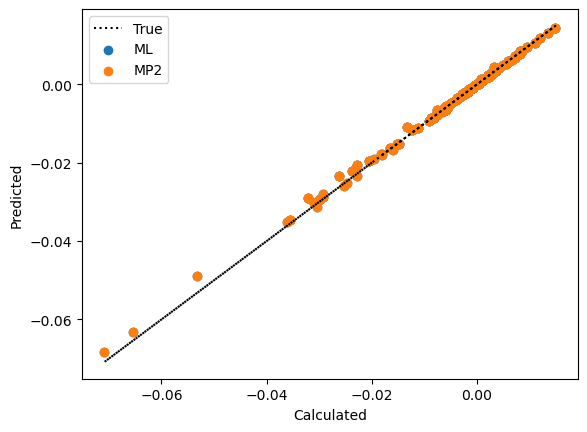

In [31]:
plt.plot(A.t2.flatten(),A.t2.flatten(),'k:',label='True')
plt.scatter(A.t2.flatten(),y_pred.flatten(),label='ML')
plt.scatter(A.t2.flatten(),A.t2start.flatten(),label='MP2')
plt.ylabel("Predicted")
plt.xlabel("Calculated")
plt.legend()
plt.show()

In [32]:
mean_absolute_error(A.t2.flatten(),y_pred.flatten()), r2_score(A.t2.flatten(),y_pred.flatten())

(0.00036181068502654813, 0.9967481779802869)

## Random initialisation

In [33]:
rand_iter_list = []
rand_dev = []
for fn in filenames[:3]:
    print(f"Processing {fn}")
    with open(fn,'r') as f:
        text=f.read()
        
    mol = psi4.geometry(text)                
    
    psi4.core.clean()
    psi4.core.be_quiet()
    
    psi4.set_options({'basis': basis_sets[0],
                      'scf_type':     'pk',
                      'reference':    'rohf',
                      'mp2_type':     'conv',
                      'e_convergence': 1e-8,
                      'd_convergence': 1e-8})
    
    rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)        # rhf_e is Hartree-Fock energy 
    scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
    
    A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=True)


    A.t1 = np.random.rand(*A.t1.shape)
    A.t2 = np.random.rand(*A.t2.shape)
    
    #  A.t2start = y_pred.reshape(*A.t2.shape)                                                            # what do I have to do here????
    
    rand_0_e = A.compute_energy(iterate=False)      # random energy
    rand = A.compute_energy()             # exact CCSD energy

    #rand_dev.append(abs(rand_0_e-rand))   # energy deviation from exact CCSD
    # NOTE: Since random may not converge, this above line may return an error

    rdmHistory = A.history               # tuple, (iteration_nunber, CCSDcorr_E)
    rdmHistory.insert(0, (0,rand_0_e))
    for i in rdmHistory:
        print(i)
    print("\n")
    
    iterations = len(rdmHistory)     # number of iterations to converge
    print(f"No. of iterations to converge: {iterations}")
    rand_iter_list.append(iterations)
    
    random_time_to_converge = A.time_to_converge 
    print(f"Time to converge: {random_time_to_converge}")
    
    features = pd.DataFrame(np.array([getattr(A,attr).flatten() for attr in properties]).T,columns=properties)
    print(f"Features: \n{features}")

print(rand_iter_list)
print(rand_dev)

Processing ../machine_learning/data/methane72.xyz
Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 9 basis functions.
(9, 9)
(8, 8)
Building initial guess...

..initialized CCSD in 0.091 seconds.

CCSD Iteration   0: CCSD correlation = 1.479705817450037   dE = -1.47971E+00   MP2
CCSD Iteration   1: CCSD correlation = 1.479705817450037   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = 1.479705817450037   dE = -1.47971E+00   MP2
CCSD Iteration   1: CCSD correlation = 1.547556505178695   dE =  6.78507E-02   DIIS = 0
CCSD Iteration   2: CCSD correlation = 2.270295114426097   dE =  7.22739E-01   DIIS = 1
CCSD Iteration   3: CCSD correlation = 1.754849526285591   dE = -5.15446E-01   DIIS = 2
CCSD Iteration   4: CCSD correlation = 1.316652010703118   dE = -4.38198E-01   DIIS = 3
CCSD Iteration   5: CCSD correlation = 1.058606976204906   dE = -2.58045E-01   DIIS = 4
CCSD Iteration   6: CCSD correlation = 1.007

/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 8 basis functions.
(8, 8)
(7, 7)
Building initial guess...

..initialized CCSD in 0.068 seconds.

CCSD Iteration   0: CCSD correlation = 1.499129968782266   dE = -1.49913E+00   MP2
CCSD Iteration   1: CCSD correlation = 1.499129968782266   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = 1.499129968782266   dE = -1.49913E+00   MP2
CCSD Iteration   1: CCSD correlation = 1.269327729510503   dE = -2.29802E-01   DIIS = 0
CCSD Iteration   2: CCSD correlation = 1.417628612326400   dE =  1.48301E-01   DIIS = 1
CCSD Iteration   3: CCSD correlation = 1.661114081332071   dE =  2.43485E-01   DIIS = 2
CCSD Iteration   4: CCSD correlation = 1.096462475449196   dE = -5.64652E-01   DIIS = 3
CCSD Iteration   5: CCSD correlation = 0.891452500722779   dE = -2.05010E-01   DIIS = 4
CCSD Iteration   6: CCSD correlation = 1.016

/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 9 basis functions.
(9, 9)
(8, 8)
Building initial guess...

..initialized CCSD in 0.383 seconds.

CCSD Iteration   0: CCSD correlation = 1.318328762570356   dE = -1.31833E+00   MP2
CCSD Iteration   1: CCSD correlation = 1.318328762570356   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = 1.318328762570356   dE = -1.31833E+00   MP2
CCSD Iteration   1: CCSD correlation = 1.435839140334272   dE =  1.17510E-01   DIIS = 0
CCSD Iteration   2: CCSD correlation = 2.566763098443917   dE =  1.13092E+00   DIIS = 1
CCSD Iteration   3: CCSD correlation = 1.602185762735200   dE = -9.64577E-01   DIIS = 2
CCSD Iteration   4: CCSD correlation = 1.369525322549334   dE = -2.32660E-01   DIIS = 3
CCSD Iteration   5: CCSD correlation = 1.679504297437690   dE =  3.09979E-01   DIIS = 4
CCSD Iteration   6: CCSD correlation = 1.465

## Zeros initialisation

In [34]:
zero_iter_list = []
zeros_dev = []
for fn in filenames[:3]:
    print(f"Processing {fn}")
    with open(fn,'r') as f:
        text=f.read()
        
    mol = psi4.geometry(text)                
    
    psi4.core.clean()
    psi4.core.be_quiet()
    
    psi4.set_options({'basis': basis_sets[0],
                      'scf_type':     'pk',
                      'reference':    'rohf',
                      'mp2_type':     'conv',
                      'e_convergence': 1e-8,
                      'd_convergence': 1e-8})
    
    rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)        # rhf_e is Hartree-Fock energy 
    scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
    
    A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=True)

    A.t1 = np.zeros(A.t1.shape)
    A.t2 = np.zeros(A.t2.shape)
    
    #  A.t2start = y_pred.reshape(*A.t2.shape)                                                            # what do I have to do here????
    
    zeros_0_e = A.compute_energy(iterate=False)      # random energy
    zeros_e = A.compute_energy()             # exact CCSD energy

    zeros_dev.append(abs(zeros_0_e-zeros_e))

    zerosHistory = A.history               # tuple, (iteration_nunber, CCSDcorr_E)
    zerosHistory.insert(0, (0,zeros_0_e))
    
    for i in zerosHistory:
        print(i)
    print("\n")
    
    iterations = len(zerosHistory)     # number of iterations to converge
    print(f"No. of iterations to converge: {iterations}")
    zero_iter_list.append(iterations)
    
    zero_time_to_converge = A.time_to_converge 
    print(f"Time to converge: {zero_time_to_converge}")
    
    features = pd.DataFrame(np.array([getattr(A,attr).flatten() for attr in properties]).T,columns=properties)
    print(f"Features: \n{features}")

print(zero_iter_list)
print(zeros_dev)

Processing ../machine_learning/data/methane72.xyz
Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 9 basis functions.
(9, 9)
(8, 8)
Building initial guess...

..initialized CCSD in 0.204 seconds.

CCSD Iteration   0: CCSD correlation = 0.000000000000000   dE = -0.00000E+00   MP2
CCSD Iteration   1: CCSD correlation = 0.000000000000000   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = 0.000000000000000   dE = -0.00000E+00   MP2
CCSD Iteration   1: CCSD correlation = -0.056348025072750   dE = -5.63480E-02   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.071291294011885   dE = -1.49433E-02   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.077955578398195   dE = -6.66428E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.078917088229280   dE = -9.61510E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.079050738114941   dE = -1.33650E-04   DIIS = 4
CCSD Iteration   6: CCSD correlation = 

/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 8 basis functions.
(8, 8)
(7, 7)
Building initial guess...

..initialized CCSD in 0.123 seconds.

CCSD Iteration   0: CCSD correlation = 0.000000000000000   dE = -0.00000E+00   MP2
CCSD Iteration   1: CCSD correlation = 0.000000000000000   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = 0.000000000000000   dE = -0.00000E+00   MP2
CCSD Iteration   1: CCSD correlation = -0.047170836330905   dE = -4.71708E-02   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.059179512125440   dE = -1.20087E-02   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.064167266482528   dE = -4.98775E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.064857980064044   dE = -6.90714E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.064950418413835   dE = -9.24383E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = 

/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 9 basis functions.
(9, 9)
(8, 8)
Building initial guess...

..initialized CCSD in 0.088 seconds.

CCSD Iteration   0: CCSD correlation = 0.000000000000000   dE = -0.00000E+00   MP2
CCSD Iteration   1: CCSD correlation = 0.000000000000000   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = 0.000000000000000   dE = -0.00000E+00   MP2
CCSD Iteration   1: CCSD correlation = -0.056220370237873   dE = -5.62204E-02   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.071130573095661   dE = -1.49102E-02   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.077776297424084   dE = -6.64572E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.078732476145068   dE = -9.56179E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.078865169719098   dE = -1.32694E-04   DIIS = 4
CCSD Iteration   6: CCSD correlation = 

In [35]:
print("Devations from the converged CCSD energies in mEh")
print(f"Abs MP2: {abs(MP2E - CCSDE) * 1e3:.4e} mEh")
print(f"Abs DDCC before iterations: {abs(mlE_0-CCSDE) * 1e3:.4e} mEh")
print(f"Abs DDCC after iterations: {abs(mlE - CCSDE) * 1e3:.4e} mEh")

Devations from the converged CCSD energies in mEh
Abs MP2: 2.2646e+01 mEh
Abs DDCC before iterations: 2.1033e+00 mEh
Abs DDCC after iterations: 1.6976e-06 mEh


In [36]:
print(np.mean(MP2_dev), np.mean(ml_dev), np.mean(zeros_dev))

0.02104113782525883 0.0014936025979291935 0.07428754890077198


In [37]:
MP2E-CCSDE

np.float64(0.022646441900923436)

In [38]:
CCSDE, mlE

(np.float64(-0.0788668121387962), np.float64(-0.07886681044117516))

In [39]:
MP2History

[(0, np.float64(-0.05622037023787277)),
 (1, np.float64(-0.07113057309566059)),
 (2, np.float64(-0.07594789762140308)),
 (3, np.float64(-0.07864873625368672)),
 (4, np.float64(-0.07884919631091017)),
 (5, np.float64(-0.07886721306959678)),
 (6, np.float64(-0.07886648577786246)),
 (7, np.float64(-0.07886686026845079))]

In [40]:
rdmHistory

[(0, np.float64(1.3183287625703557)),
 (1, np.float64(1.4358391403342718)),
 (2, np.float64(2.5667630984439174)),
 (3, np.float64(1.6021857627351996)),
 (4, np.float64(1.3695253225493345)),
 (5, np.float64(1.6795042974376904)),
 (6, np.float64(1.4657398185867268)),
 (7, np.float64(1.1871399017116935)),
 (8, np.float64(1.1878303412249644)),
 (9, np.float64(1.1928235329693868)),
 (10, np.float64(1.1740562872400835)),
 (11, np.float64(1.3525317251075852)),
 (12, np.float64(1.6688569315759987)),
 (13, np.float64(1.2337058078723044)),
 (14, np.float64(1.1304493097917387)),
 (15, np.float64(1.0760933951434946)),
 (16, np.float64(1.781661764599893)),
 (17, np.float64(1.6969836926408084)),
 (18, np.float64(1.403870068399645)),
 (19, np.float64(1.4272817236564328)),
 (20, np.float64(1.4207487375339733)),
 (21, np.float64(1.499868792825653)),
 (22, np.float64(1.5328665360344012)),
 (23, np.float64(1.3528679844101528)),
 (24, np.float64(1.5460093308771272)),
 (25, np.float64(1.537749689491303)),


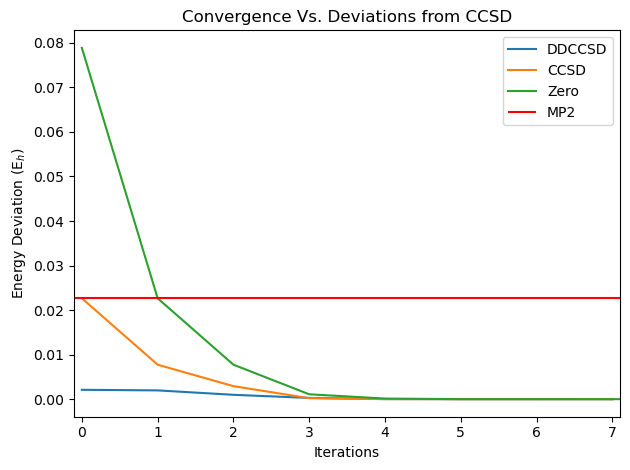

In [42]:
plt.plot(np.array(mlHistory)[:,0].T,np.array(mlHistory)[:,1].T-CCSDE,label='DDCCSD')
plt.plot(np.array(MP2History)[:,0].T,np.array(MP2History)[:,1].T-CCSDE,label='CCSD')
#plt.plot(np.array(rdmHistory)[:,0].T,np.array(rdmHistory)[:,1].T-CCSDE,label='Random')
plt.plot(np.array(zerosHistory)[:,0].T,np.array(zerosHistory)[:,1].T-CCSDE,label='Zero')
plt.hlines(MP2E-CCSDE,-1,50,color='r',label='MP2')
plt.xlim(0-0.1,len(MP2History)-0.9)
# plt.ylim(-1e-3,9e-3)
plt.ylabel("Energy Deviation (E$_{h}$)")
plt.xlabel("Iterations")
plt.legend()
plt.title('Convergence Vs. Deviations from CCSD')
plt.tight_layout()
plt.show()